## Step-by-step boosting walkthrough

In this example, we will go through a few iterations a simple boosting approach for training an ensemble of decision tree regressors. This is actually a special case of [*gradient boosting*](https://en.wikipedia.org/wiki/Gradient_boosting).

To run the example on your own, you will need to make sure that the `graphviz` library is installed if you want to draw the decision trees. (For instance, in Anaconda you write `conda install python-graphviz`.)

In [1]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.dummy import DummyRegressor
import graphviz
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn-v0_8')

We first make some synthetic data. The input is just one-dimensional, so that we can easily visualize what is going on.

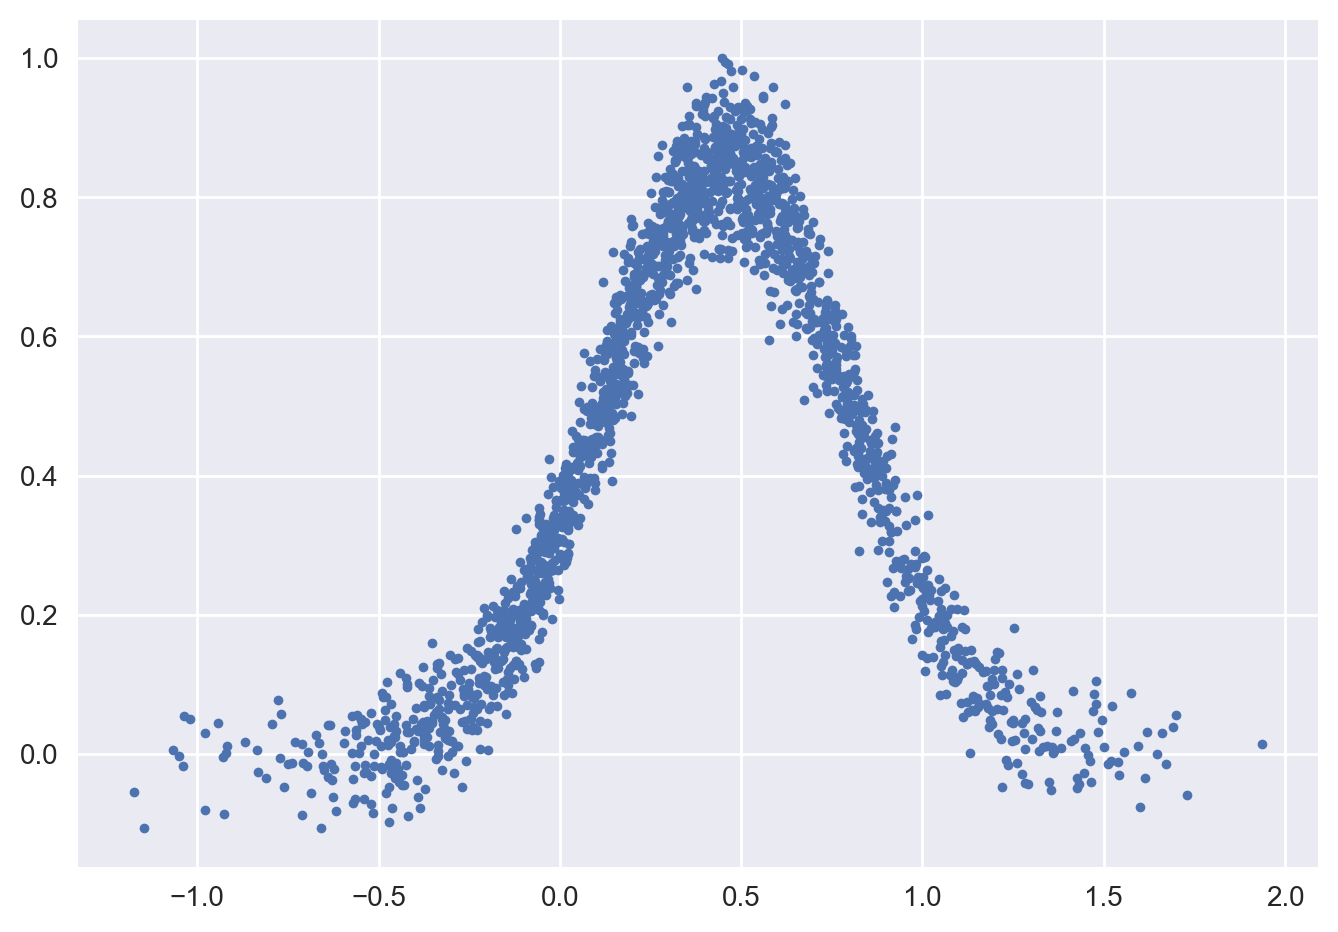

In [2]:
def make_data():
    N = 2000
    X = 0.5*np.random.normal(size=N)+0.35

    Xt = 0.75*X-0.35
    X = X.reshape((N, 1))

    Y = -(8 * Xt**2 + 0.1*Xt + 0.1) + 0.05 * np.random.normal(size=N)
    Y = np.exp(Y) + 0.05 * np.random.normal(size=N)
    Y /= max(np.abs(Y))
    return X, Y


np.random.seed(0)
X, Y = make_data()

plt.plot(X[:, 0], Y, '.');

In gradient boosting, and in boosting in general, we train models that try to correct the errors of the previous step.

Our starting point is a "dummy regressor" $h_0$ that always outputs a constant value.

In [3]:
h0 = DummyRegressor()
h0.fit(X, Y);

Let's plot the output of the first regression model. As you can see, the predictions aren't fantastic at this point.

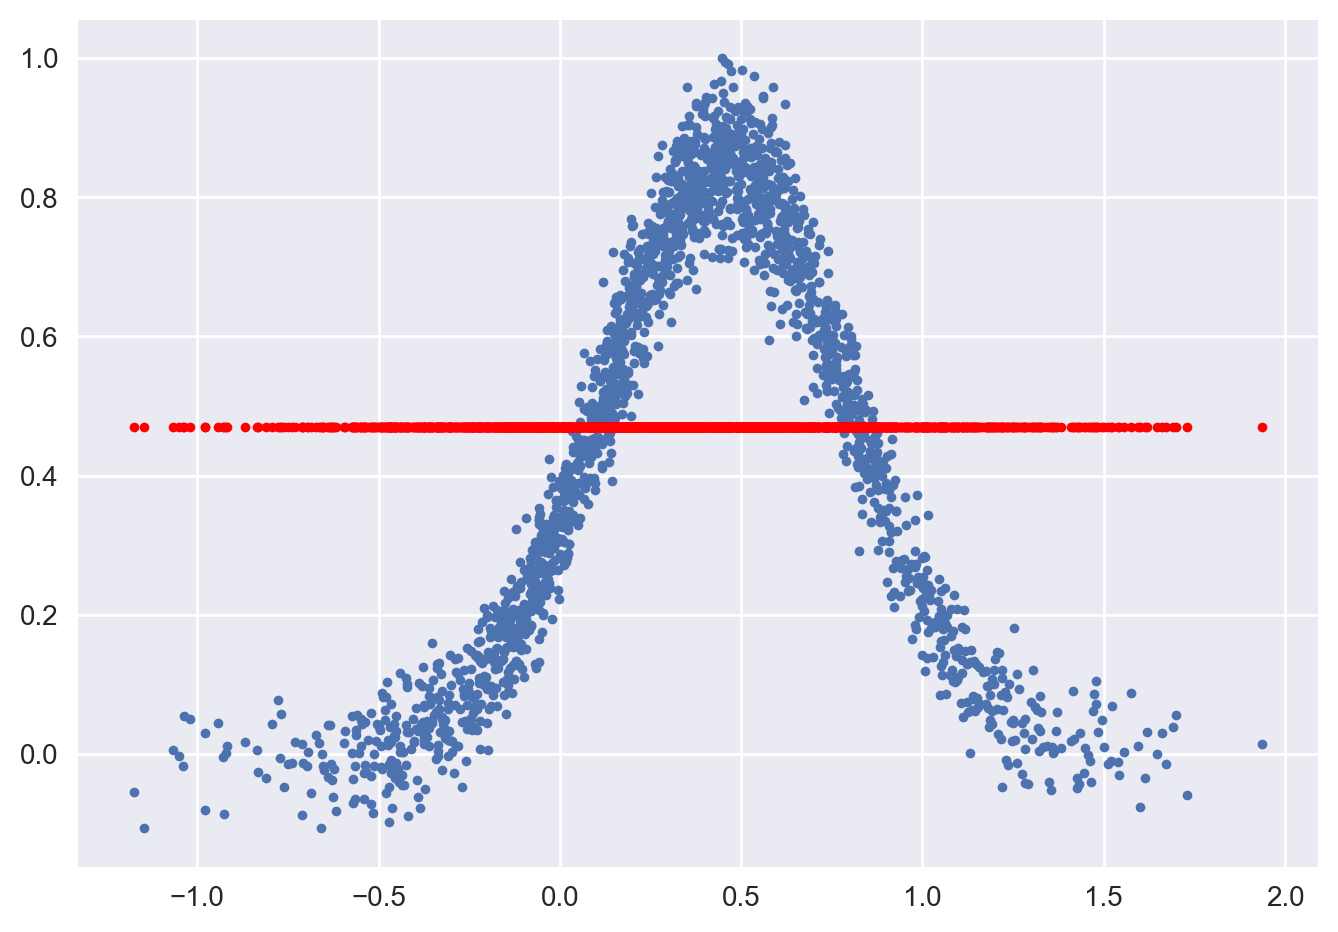

In [4]:
plt.plot(X[:, 0], Y, '.')
plt.plot(X[:, 0], h0.predict(X), 'r.')

We will now build the next regression model $h_1$, based on the errors of the previous model $h_0$.

First, let's build the *residuals* `Y0`: the difference between the desired outputs and the outputs by the previous regressor. (As you can see, this is just the original `Y`, but shifted by a constant value.) We also include the standard deviation $\sigma$ in this plot.

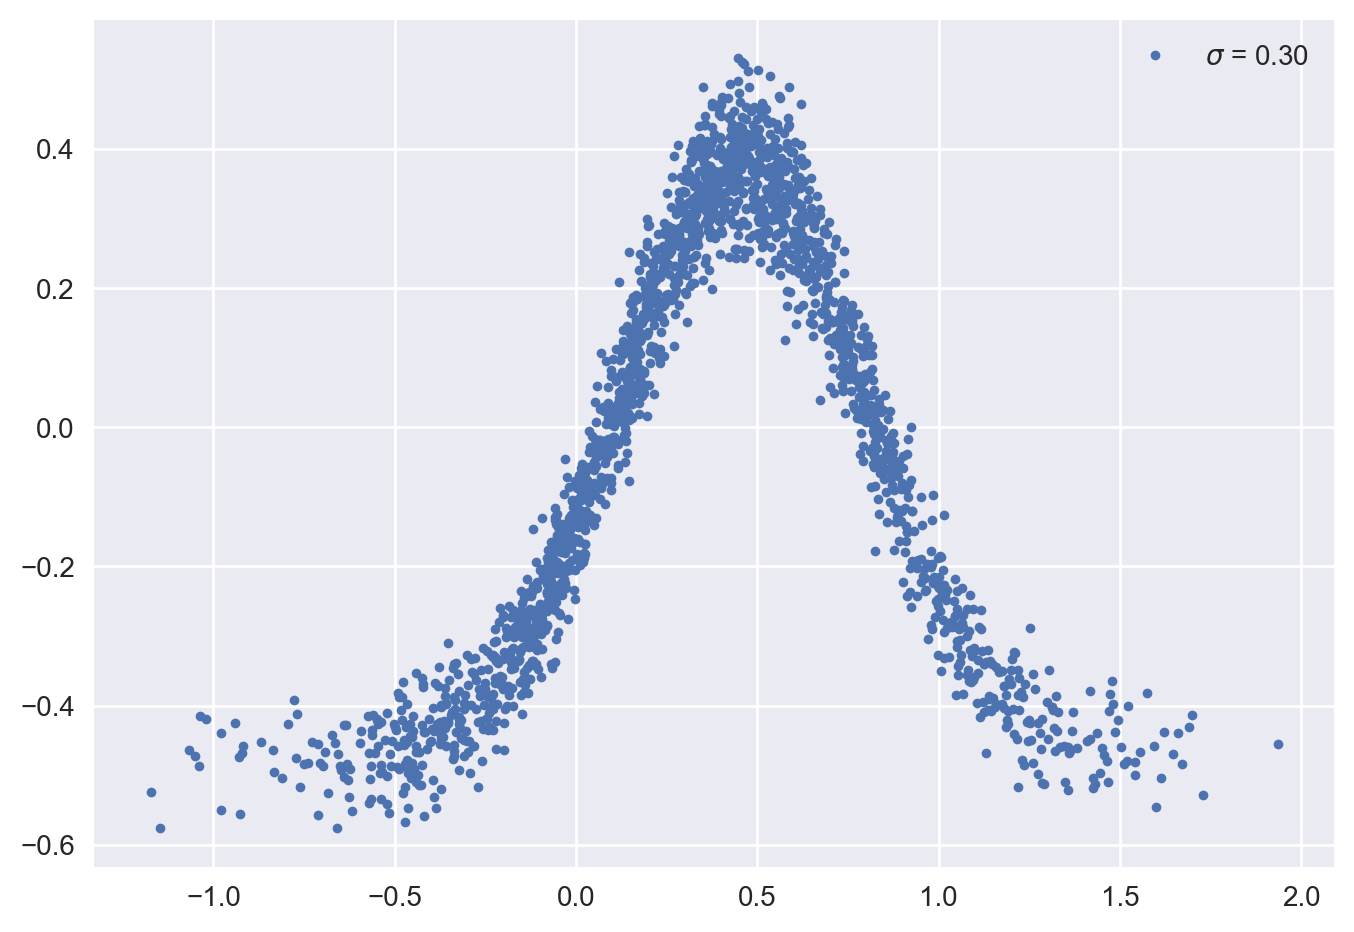

In [5]:
Y0 = Y - h0.predict(X)
plt.plot(X[:, 0], Y0, '.')
plt.legend([r'$\sigma$ = {:.2f}'.format(Y0.std())]);

Now, let's build $h_1$, which will be a small decision tree regression model trained on the residuals. We can interpret this as that our new tree tries to correct the errors in the outputs of the previous step.

In [6]:
h1 = DecisionTreeRegressor(max_depth=1)
# fit h1 to the residuals Y0
h1.fit(X, Y0);

We make a small helper function that draws the decision tree. This relies on the `export_graphviz` function in scikit-learn.

In [7]:
def draw_decision_tree(tree):
    dot_data = export_graphviz(tree, out_file=None, filled=True,
                               rounded=True, impurity=False,
                               feature_names=['x'],
                               special_characters=True)
    return graphviz.Source(dot_data)

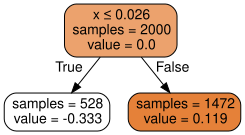

In [8]:
draw_decision_tree(h1)

As you can see, this tree splits at $x =$ 0.026. For smaller values, the tree outputs -0.333 and for larger values it outputs 0.119.

Let's plot the residuals and the prediction of this tree.

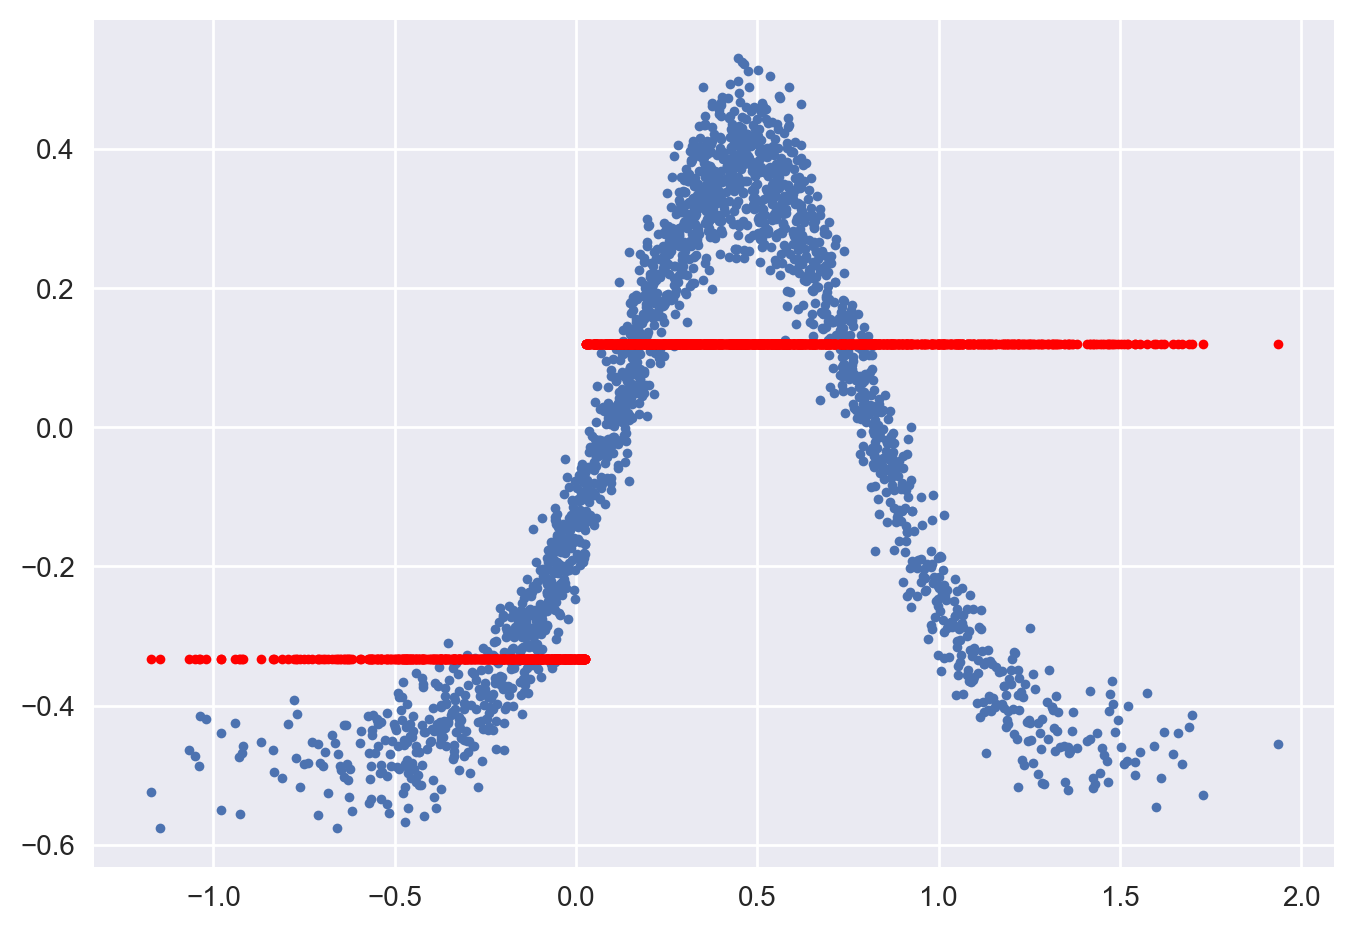

In [9]:
plt.plot(X[:, 0], Y0, '.')
plt.plot(X[:, 0], h1.predict(X), 'r.');

Now, we compute new residuals: the difference between the previous residuals, and the prediction by out latest tree regression model.

We plot these residuals and also compute the standard deviation. As you can see, $\sigma$ is lower now.

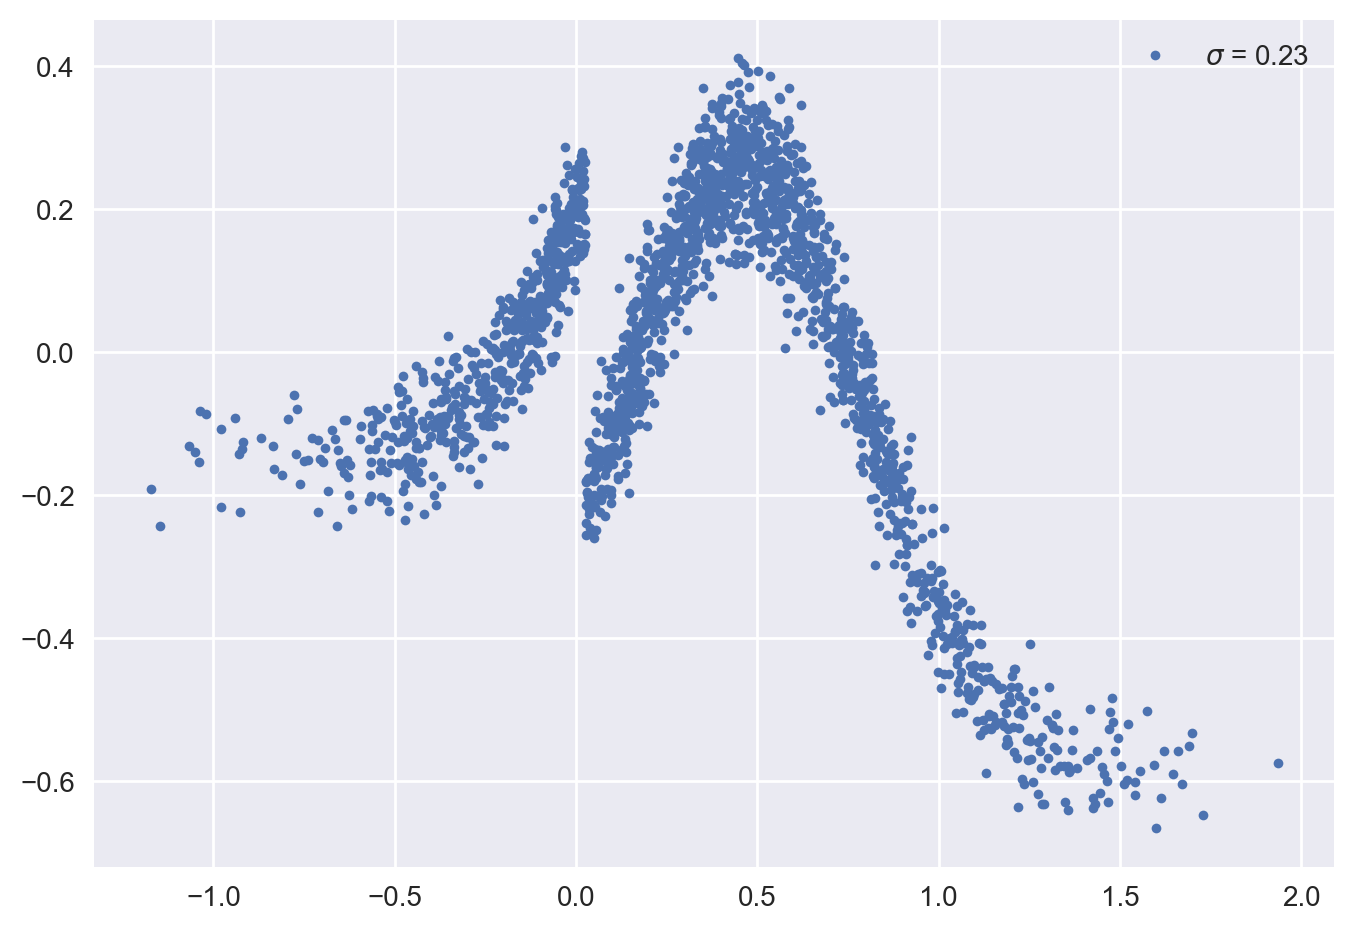

In [10]:
Y1 = Y0 - h1.predict(X)
plt.plot(X[:, 0], Y1, '.')
plt.legend([r'$\sigma$ = {:.2f}'.format(Y1.std())]);

We repeat the procedure from above: we first fit a new tree model $h_2$ to the latest residuals.

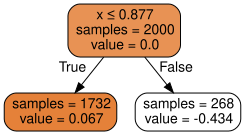

In [11]:
h2 = DecisionTreeRegressor(max_depth=1)
h2.fit(X, Y1)
draw_decision_tree(h2)

... and we plot the predictions to see how well they fit the residuals ...

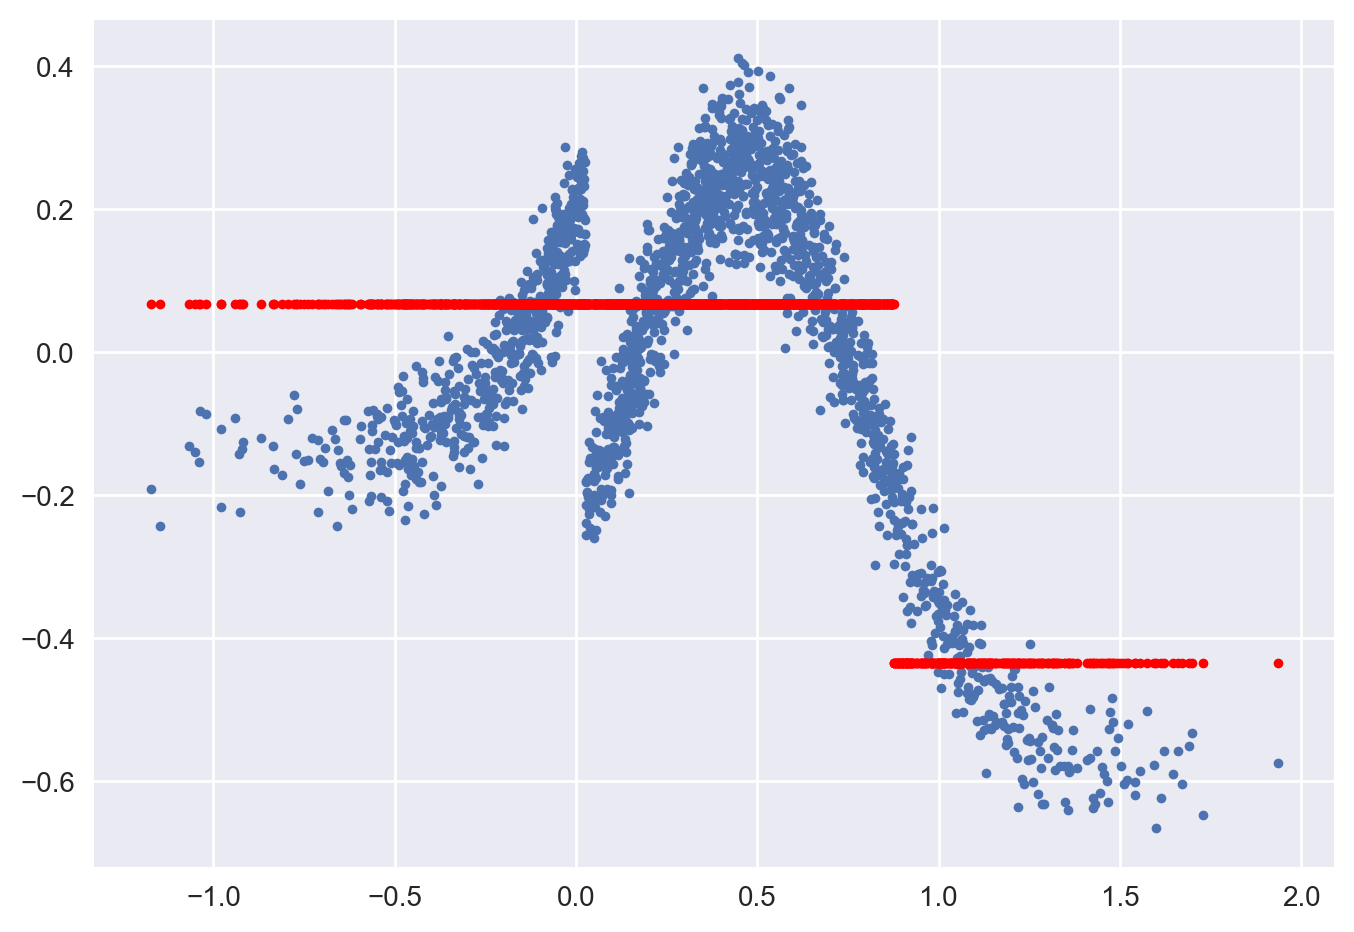

In [12]:
plt.plot(X[:, 0], Y1, '.')
plt.plot(X[:, 0], h2.predict(X), 'r.');

... and again compute new residuals ...

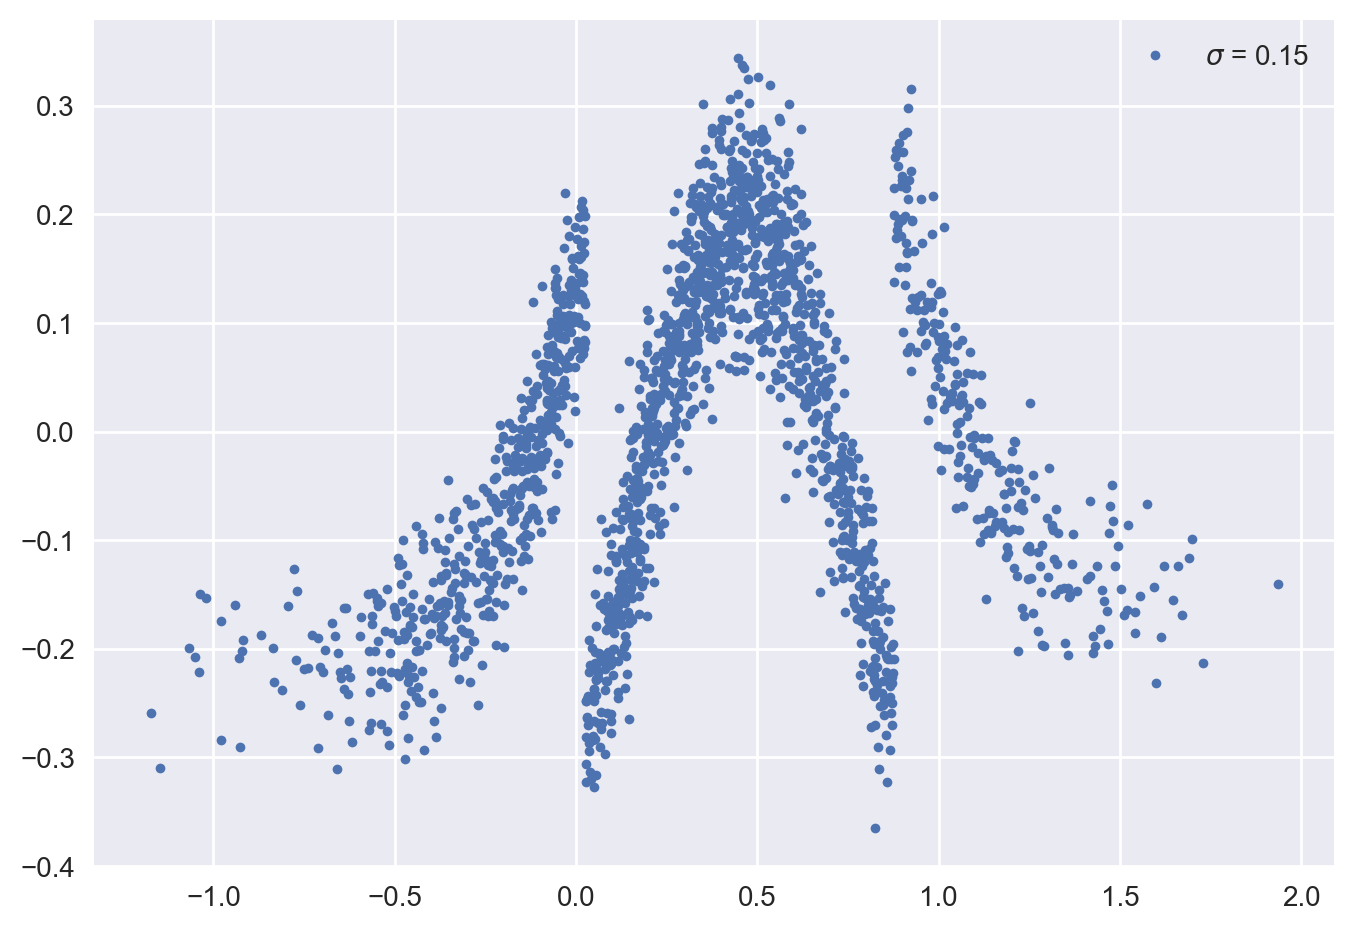

In [13]:
Y2 = Y1 - h2.predict(X)
plt.plot(X[:, 0], Y2, '.')
plt.legend([r'$\sigma$ = {:.2f}'.format(Y2.std())]);

... and again a new tree $h_3$ ...

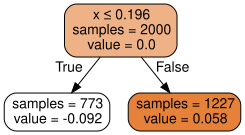

In [14]:
h3 = DecisionTreeRegressor(max_depth=1)
h3.fit(X, Y2)
draw_decision_tree(h3)

... and see how this tree fits the residuals ...

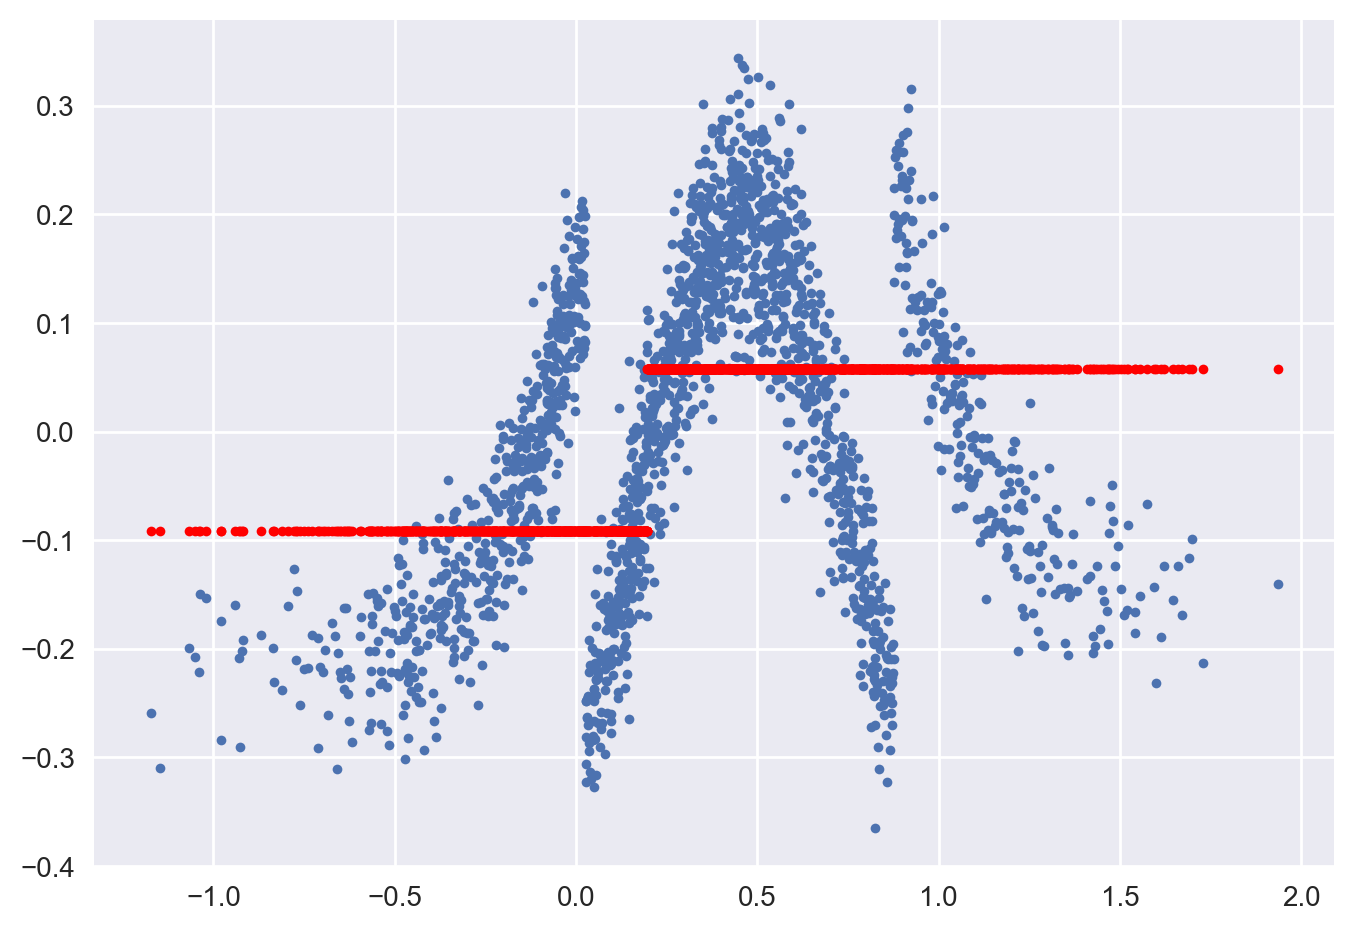

In [15]:
plt.plot(X[:, 0], Y2, '.')
plt.plot(X[:, 0], h3.predict(X), 'r.');

... and finally again compute new residuals.

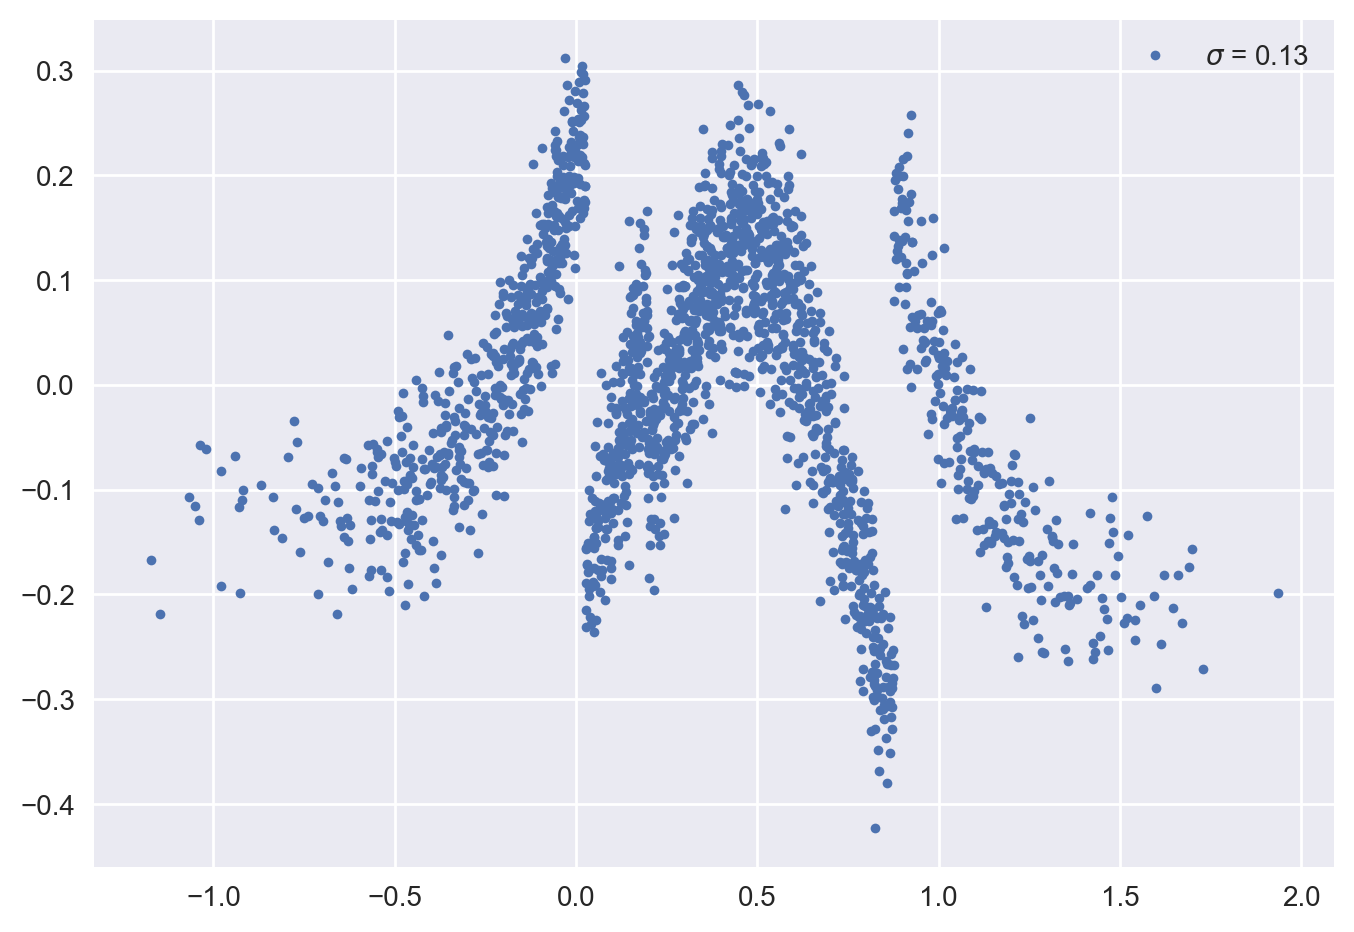

In [16]:
Y3 = Y2 - h3.predict(X)
plt.plot(X[:, 0], Y3, '.')
plt.legend([r'$\sigma$ = {:.2f}'.format(Y3.std())]);

### Putting the pieces together

Now that we have iterated this process a few times, you probably get the hang of it. Let's see how well the complete ensemble predicts the original data.

The output of the ensemble is defined as the sum of all the sub-regressors: $F(x) = h_0(x) + h_1(x) + h_2(x) + h_3(x)$. As you can see, our predictions are still imperfect: we'd need more iterations of boosting to get a better fit.

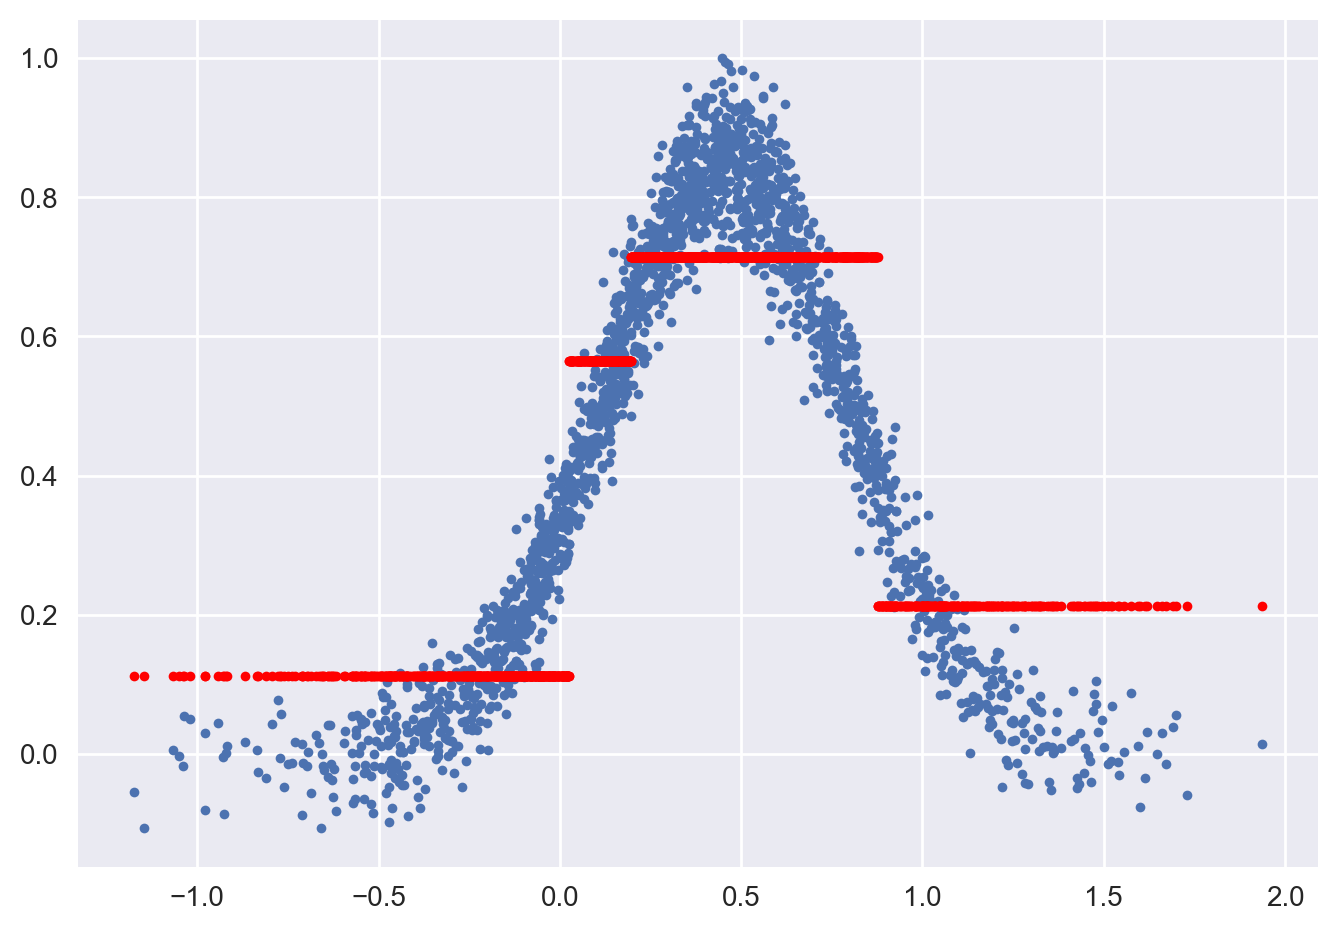

In [17]:
def predict_ensemble(trees, X):
    out = np.zeros(X.shape[0])
    for tree in trees:
        out += tree.predict(X)
    return out


ensemble_prediction = predict_ensemble([h0, h1, h2, h3], X)

plt.plot(X[:, 0], Y, '.')
plt.plot(X[:, 0], ensemble_prediction, 'r.');

Instead of iterating manually as we did above, let's write a function that carries out the iteration:

In [18]:
def train_ensemble_boosting(X, Y, n_estimators):
    residuals = Y.copy()
    h = DummyRegressor()
    h.fit(X, residuals)
    E = [h]
    for _ in range(n_estimators-1):
        residuals -= h.predict(X)
        h = DecisionTreeRegressor(max_depth=1).fit(X, residuals)
        E.append(h)
    return E

For instance, we train an ensemble consisting of 16 sub-models:

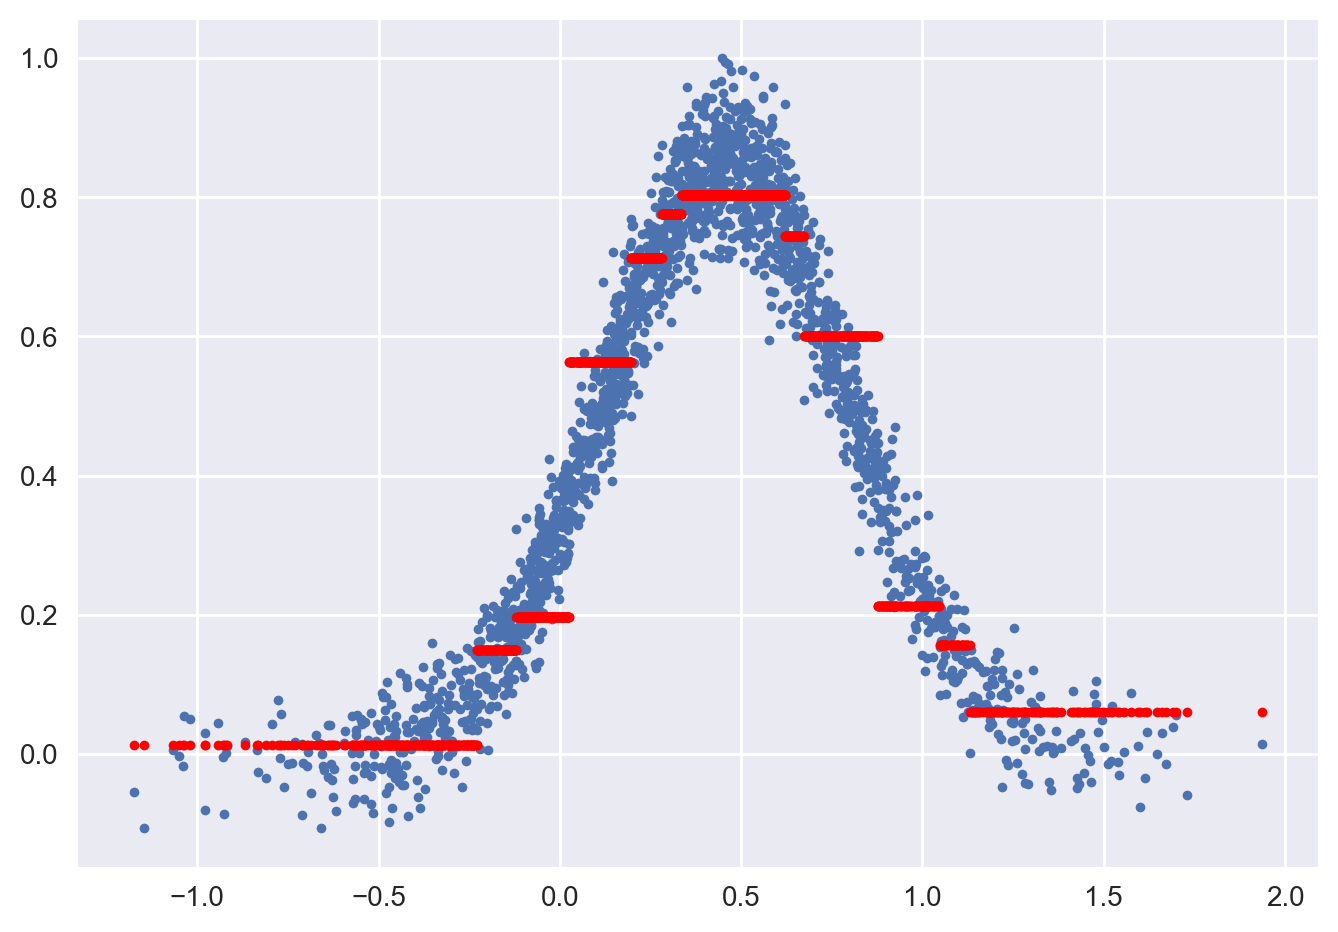

In [19]:
ensemble = train_ensemble_boosting(X, Y, 16)

ensemble_prediction = predict_ensemble(ensemble, X)

plt.plot(X[:, 0], Y, '.')
plt.plot(X[:, 0], ensemble_prediction, 'r.');

The following figure illustrates how the complexity of the ensemble gradually increases, as we add more and more sub-regressors.

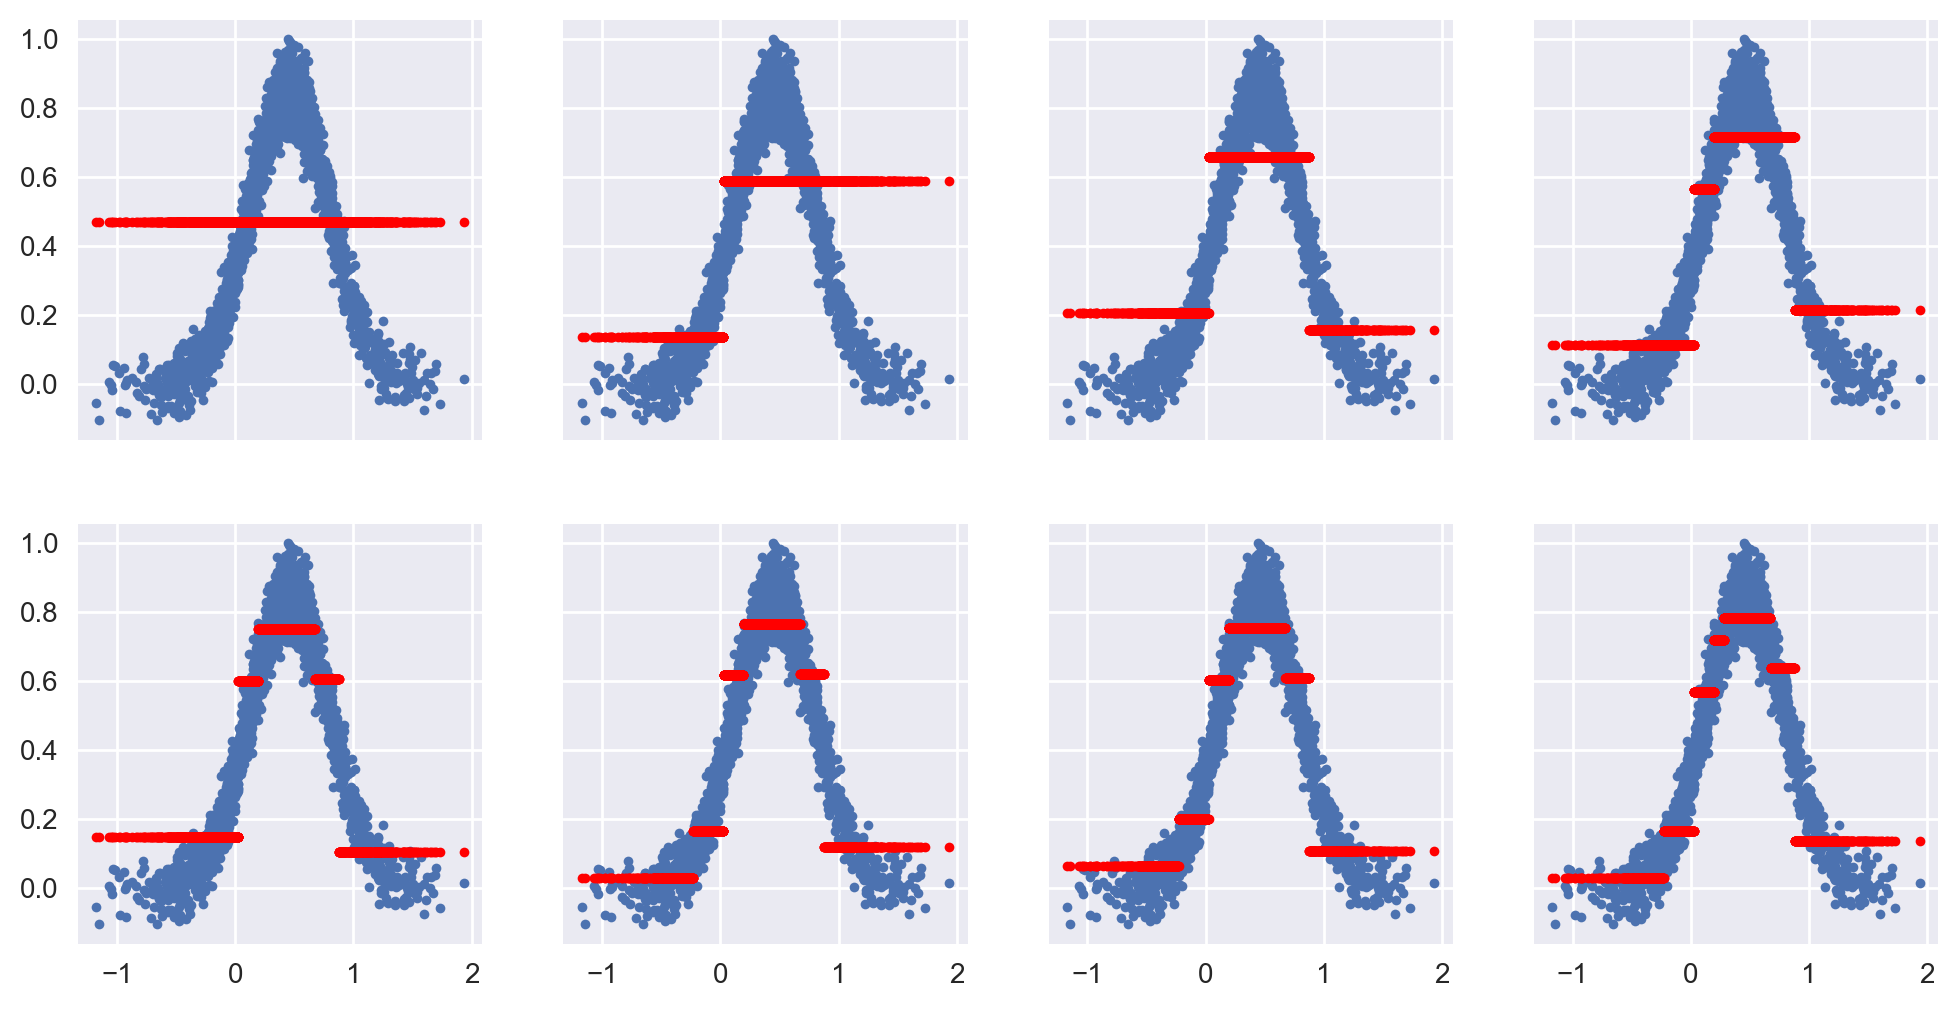

In [20]:
f, A = plt.subplots(2, 4, sharex='col', sharey='row', figsize=(2*6, 1*6))
A = [a for r in A for a in r]
for i, a in enumerate(A):
    ensemble_prediction = predict_ensemble(ensemble[:(i+1)], X)
    a.plot(X[:, 0], Y, '.')
    a.plot(X[:, 0], ensemble_prediction, 'r.');